#**유통 판매량 예측 및 재고 최적화**
## **단계3 : 모델링 및 비즈니스 평가**

# **0.미션**

* 단계1 다양한 모델링 수행
    * LSTM, CNN 등을 이용해서 다양한 시계열 모델링 수행
    * 성능 상위 2~3개 모델 선정
* 단계2 데이터 파이프라인 구축
    * test 데이터(raw data)로 부터 예측에 사용할 수 있는 형태로 데이터를 만드는 과정을 하나의 함수로 엮기
* 단계3 비즈니스 평가
    * 단계1에서 선정된 모델에 대해 test셋으로 평균 재고액 평가 수행

* 대상 상품(핵심 상품)

| Product_ID|Product_Code|SubCategory|Category|LeadTime|Price|
|----|----|----|----|----|----|
|3|DB001|Beverage|Drink|2|8|
|12|GA001|Milk|Food|3|6|
|42|FM001|Agricultural products|Grocery|3|5|


# **1.환경설정**

* 세부 요구사항
    * 구글콜랩
        * 구글 드라이브 바로 밑에 project 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 라이브러리 로딩
        * 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### **(1) 경로 설정**

* 구글 드라이브 연결

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
path = '/content/drive/MyDrive/project/'

### **(2) 라이브러리 설치 및 불러오기**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm

from keras.models import Sequential
from keras.backend import clear_session
from keras.layers import Dense, LSTM, Conv1D, Flatten, Bidirectional
from keras.optimizers import Adam

import warnings
warnings.filterwarnings("ignore")

In [17]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

In [18]:
# 예측 결과 시각화
def plot_model_result(y_train, y_val, pred) :

    y_train = pd.Series(y_train)
    y_val = pd.Series(y_val)
    y_val.index = range(len(y_train), len(y_train) + len(y_val))

    pred = pd.Series(pred.reshape(-1,), index = y_val.index)

    # 전체 시각화
    plt.figure(figsize = (20,12))
    plt.subplot(2,1,1)
    plt.plot(y_train, label = 'train')
    plt.plot(y_val, label = 'val')
    plt.plot(pred, label = 'pred')
    plt.legend()
    plt.grid()

    plt.subplot(2,1,2)
    plt.plot(y_val, label = 'val')
    plt.plot(pred, label = 'pred')
    plt.legend()
    plt.grid()

    plt.show()

### **(3) 데이터 불러오기**

* **세부 요구사항**
    - 상품별로 저장한 데이터를 불러오시오.

* 대상 상품(핵심 상품)

| Product_ID|Product_Code|SubCategory|Category|LeadTime|Price|
|----|----|----|----|----|----|
|3|DB001|Beverage|Drink|2|8|
|12|GA001|Milk|Food|3|6|
|42|FM001|Agricultural products|Grocery|3|5|


In [23]:

df_bev = joblib.load(path+'data_beverage.pkl')
# milk = joblib.load('/content/drive/MyDrive/project6/data_12.pkl')
# grocery = joblib.load('/content/drive/MyDrive/project6/df_44_42.pkl')

In [ ]:
df_bev.head()

,CustomerCount,Qty,WTI_Price,month,BAKERY,Home Appliances,Yogurt,2d_later,day_1,day_2,day_3,day_4,day_5,day_6,season_2,season_3,season_4
0,4422.0,9853.0,95.14,1,1302.470,41.0,2991.0,15153.0,False,False,True,False,False,False,False,False,True
1,4167.0,8647.0,93.66,1,1243.054,40.0,2694.0,15606.0,False,False,False,True,False,False,False,False,True
2,5341.0,15153.0,93.48,1,1882.780,90.0,4355.0,7900.0,False,False,False,False,True,False,False,False,True
3,5123.0,15606.0,93.30,1,2029.317,96.0,4228.0,7188.0,False,False,False,False,False,True,False,False,True
4,3917.0,7900.0,93.12,1,992.359,33.0,2323.0,8800.0,False,False,False,False,False,False,False,False,True


In [ ]:
milk.head()

,Date,Qty,CustomerCount,WTI_Price,Month,Weekday,Is_Weekend,Prev_Qty,Qty_Weekly,Target_Qty
1,2014-01-02,9647.0,4422.0,95.140000,1,3,0,0.0,72915.0,14188.0
2,2014-01-03,8879.0,4167.0,94.770000,1,4,0,9647.0,72915.0,14490.0
3,2014-01-04,14188.0,5341.0,94.770000,1,5,1,8879.0,72915.0,7614.0
4,2014-01-05,14490.0,5123.0,94.770000,1,6,1,14188.0,72915.0,7124.0
5,2014-01-06,7614.0,3917.0,94.504444,1,0,0,14490.0,59904.0,8683.0


In [ ]:
grocery.head()

,Date,Qty,WTI_Price,CustomerCount,meat_Qty,WeekDay,Month,target
0,2014-01-02,76.0,95.140000,4422,981.64400,Thursday,1,78.0
1,2014-01-03,74.0,93.660000,4167,1278.90810,Friday,1,88.0
2,2014-01-04,78.0,93.436815,5341,1398.66600,Saturday,1,65.0
3,2014-01-05,88.0,93.167006,5123,1119.53500,Sunday,1,78.0
4,2014-01-06,65.0,93.120000,3917,526.12897,Monday,1,73.0


# **2.모델링**

* **세부 요구사항**
    * 3차원 데이터 구조 만들기
        * timestep 수는 적절한 간격으로 한가지 경우만 지정을 합니다.
    * LSTM, CNN 기반 초기 모델 생성
        * 성능 보다는 코드 틀을 작성하는데 집중합시다.
        * 노드 혹은 필터 수와 크기는 초기값으로 적절하게 지정해 봅시다.
    * 데이터 파이프라인 함수 작성하기
        * input : raw data
        * output : x_train, x_val, y_train, y_val
        * 원본 데이터에서 일부를 떼어 놓고, 파이프라인 함수를 테스트 해 봅시다.

In [13]:
def temporalize(x, y, timesteps):
    output_X = []
    output_y = []
    for i in range(len(x) - timesteps + 1):
        output_X.append(x.iloc[i:i+timesteps])
        output_y.append(y.iloc[i+timesteps-1])
    return np.array(output_X), np.array(output_y)

## **(1) LSTM 모델링**

### **1) 상품 : 3 - Beverage**

* **데이터 준비**

In [ ]:
y = df_bev['2d_later']
x = df_bev.drop(columns=['2d_later'])

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)  # x만 스케일링

x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

x_scaled, y = temporalize(x_scaled,y,60)

y = scaler.fit_transform(y.reshape(-1,1))
x_test, y_test = x_scaled[-60:], y[-60:]
x_train, y_train = x_scaled[:-60], y[:-60]


x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2)


print("x_train shape:", x_train.shape)
print("x_val shape:", x_val.shape)
print("x_test shape:", x_test.shape)

x_train shape: (820, 60, 16)
x_val shape: (205, 60, 16)
x_test shape: (60, 60, 16)


In [ ]:
from keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

* **모델링**

In [ ]:
clear_session()

model_b = Sequential()
model_b.add(LSTM(256, input_shape=(x_train.shape[1], x_train.shape[2]), return_sequences=True))
model_b.add(LSTM(64, return_sequences=True))
model_b.add(LSTM(16, return_sequences=True))
model_b.add(LSTM(4))

# 출력층
model_b.add(Dense(1))

model_b.compile(loss='mse', optimizer='adam', metrics=['mae'])
model_b.summary()

hist = model_b.fit(x_train, y_train, epochs=300, batch_size=64, validation_data=(x_val, y_val), callbacks=[es]).history

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 256)             │         279,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 60, 64)              │          82,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 60, 16)              │           5,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 4)                   │             336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 367,253 (1.40 MB)

 Trainable params: 367,253 (1.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.0304 - mae: 0.1319 - val_loss: 0.0196 - val_mae: 0.1187
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0186 - mae: 0.1086 - val_loss: 0.0169 - val_mae: 0.0960
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0196 - mae: 0.1082 - val_loss: 0.0166 - val_mae: 0.1032
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0187 - mae: 0.1097 - val_loss: 0.0162 - val_mae: 0.0975
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0197 - mae: 0.1087 - val_loss: 0.0162 - val_mae: 0.1024
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0190 - mae: 0.1104 - val_loss: 0.0164 - val_mae: 0.1049
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0197 - mae: 0.1133 - val_loss: 0.0163 - val_mae: 0.0994
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0194 - mae: 0.1087 - val_loss: 0.0162 - val_mae: 0.1040
Epoch 9/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - lo

In [ ]:
pred = model_b.predict(x_test)
pred = scaler.inverse_transform(pred)
y_test_org = scaler.inverse_transform(y_test)
pred = pd.DataFrame(pred)

print('MAE : ', mean_absolute_error(y_test_org, pred))
print('MAPE : ',mean_absolute_percentage_error(y_test_org, pred))
print('R2 : ',r2_score(y_test_org, pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 430ms/step
MAE :  1659.4131347656253
MAPE :  0.1370307628108876
R2 :  0.5604213553414417


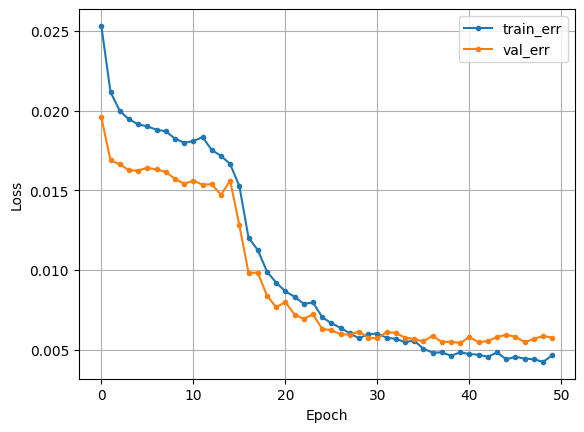

In [ ]:
dl_history_plot(hist)

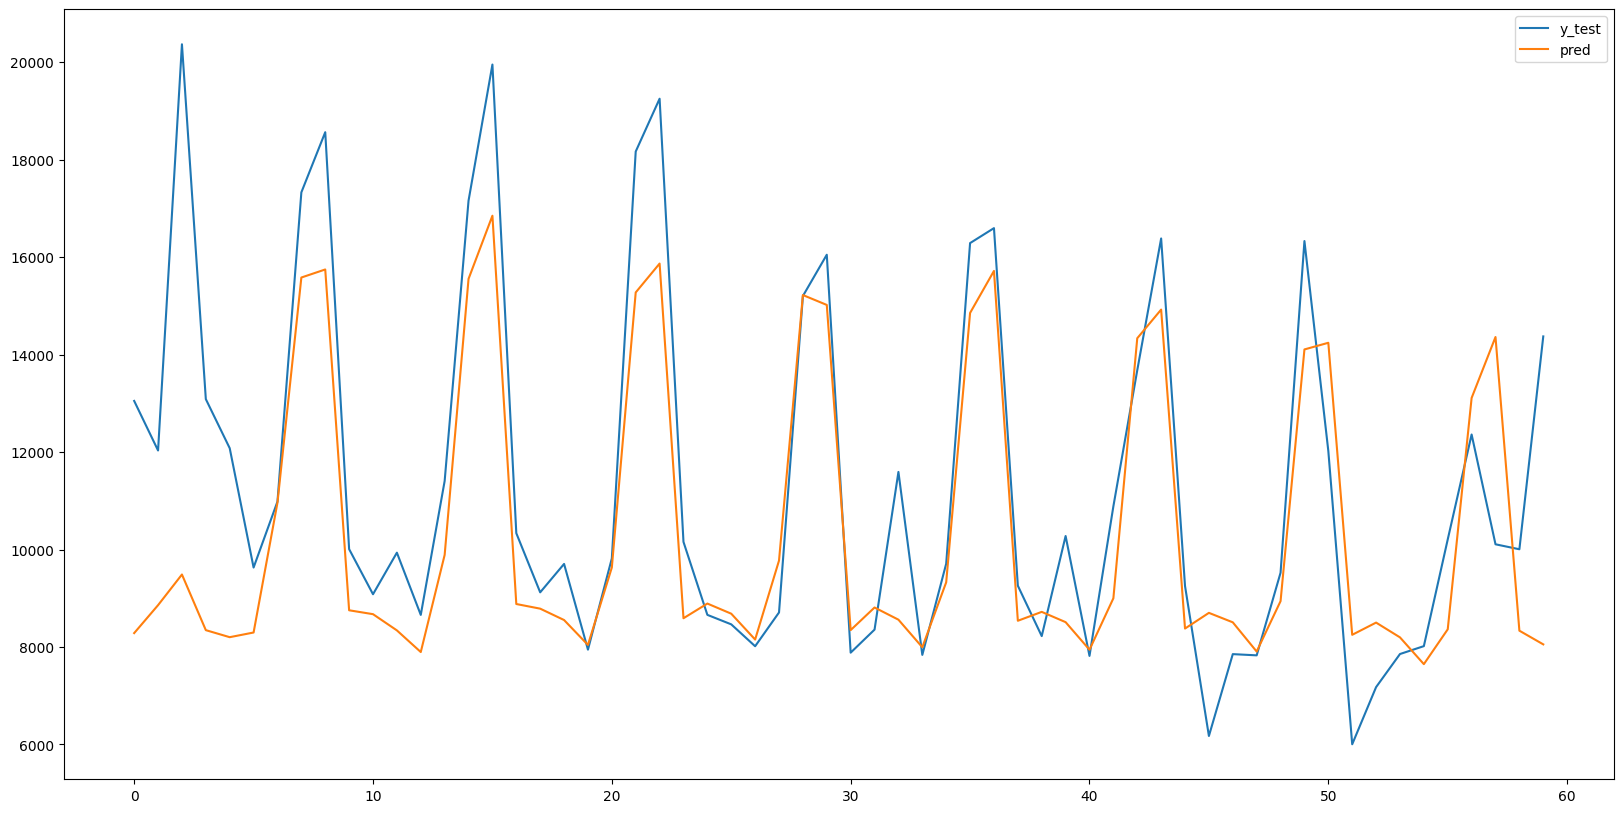

In [ ]:
plt.figure(figsize=(20,10))
plt.plot(y_test_org,label='y_test')
plt.plot(pred,label='pred')
plt.legend()
plt.show()

### **2) 상품 : 12 - Milk**

* **데이터 준비**

* **모델링**

In [ ]:
def preproc(data, y_scale=False):
    target = 'Target_Qty'  # 타겟 변수 컬럼명 수정
    x = data.drop(['Date', target], axis=1)
    y = data[target]

    # 가변수화 (범주형 변수 처리)
    x['Weekday'] = pd.Categorical(x['Weekday'], categories = [0,1,2,3,4,5,6])
    x['Is_Weekend'] = pd.Categorical(x['Is_Weekend'], categories = [0,1])
    x['Month'] = pd.Categorical(x['Month'], categories = [1,2,3,4,5,6,7,8,9,10,11,12])
    x = pd.get_dummies(x, columns = ['Weekday','Month', 'Is_Weekend'])

    # 스케일링
    scaler = MinMaxScaler()
    x = scaler.fit_transform(x)

    # y scale (0과 1 사이로 정규화)
    if y_scale:
        y_min, y_max = y.min(), y.max()
        y = (y - y_min) / (y_max - y_min)
    else:
        y_min, y_max = np.nan, np.nan

    # 데이터 분할 (훈련 세트, 검증 세트)
    x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=60, shuffle=False)

    return x_train, x_val, y_train, y_val, scaler, y_min, y_max



In [ ]:
def preproc3d(data, timesteps, y_scale = False) :
    target = 'Target_Qty'  # 타겟 변수 컬럼명 수정
    x = data.drop(['Date', target], axis=1)
    y = data[target]

    # 가변수화 (범주형 변수 처리)
    x['Weekday'] = pd.Categorical(x['Weekday'], categories = [0,1,2,3,4,5,6])
    x['Is_Weekend'] = pd.Categorical(x['Is_Weekend'], categories = [0,1])
    x['Month'] = pd.Categorical(x['Month'], categories = [1,2,3,4,5,6,7,8,9,10,11,12])
    x = pd.get_dummies(x, columns = ['Weekday', 'Month', 'Is_Weekend'], drop_first=True)
    col_names = list(x)

    # 스케일링
    scaler = MinMaxScaler()
    x = scaler.fit_transform(x)
    x = pd.DataFrame(x, columns=col_names)

    # y scale (0과 1 사이로 정규화)
    if y_scale:
        y_min, y_max = y.min(), y.max()
        y = (y - y_min) / (y_max - y_min)
    else:
        y_min, y_max = np.nan, np.nan

    # 3차원 변환
    x3, y3 = temporalize(x, y, timesteps)

    # 데이터 분할 (훈련 세트, 검증 세트)
    x_train, x_val, y_train, y_val = train_test_split(x3, y3, test_size=60, shuffle=False)

    return x_train, x_val, y_train, y_val, scaler, y_min, y_max

In [ ]:
timesteps = 7
x_train12, x_val12, y_train12, y_val12, scaler, y_min, y_max = preproc3d(milk, timesteps, True)
y_min, y_max, x_train12.shape, x_val12.shape

(0.0, 37106.0, (1078, 7, 23), (60, 7, 23))

In [ ]:
clear_session()

_, ts, nfeat = x_train12.shape

model12_01 = Sequential([LSTM(500, input_shape = (ts, nfeat) ),
                         Dense(1)])
model12_01.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 500)                 │       1,048,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             501 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,048,501 (4.00 MB)

 Trainable params: 1,048,501 (4.00 MB)

 Non-trainable params: 0 (0.00 B)

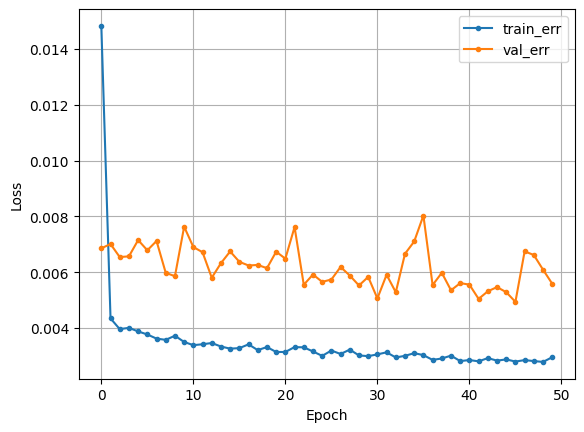

In [ ]:
model12_01.compile(optimizer = 'adam', loss = 'mse')
hist = model12_01.fit(x_train12, y_train12, epochs = 50, validation_data=(x_val12, y_val12), verbose = 0).history
dl_history_plot(hist)

In [ ]:
LSTM_model2 = Sequential([LSTM(32, input_shape=(ts, nfeat), return_sequences=True),
                          Dropout(0.2),
                          LSTM(16, return_sequences=True),
                          Dropout(0.2),
                          LSTM(8, return_sequences=False),
                          Dropout(0.2),
                          Dense(1)])

LSTM_model2.summary()

LSTM_model2.compile(optimizer = 'adam', loss = 'mse')
LSTM_hist2 = LSTM_model2.fit(x_train, y_train, epochs = 150, validation_split = .2).history
dl_history_plot(LSTM_hist2)

In [ ]:
# 스케일링 된 데이터 돌려서 평가하기
pred = model12_01.predict(x_val12)
pred = pred * (y_max - y_min) + y_min
y_val2 = y_val12 * (y_max - y_min) + y_min

print('MAE : ', mean_absolute_error(y_val2, pred))
print('MAPE : ',mean_absolute_percentage_error(y_val2, pred))
print('R2 : ',r2_score(y_val2, pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
MAE :  1886.41123046875
MAPE :  9.502471335441683e+17
R2 :  0.37892988247588844


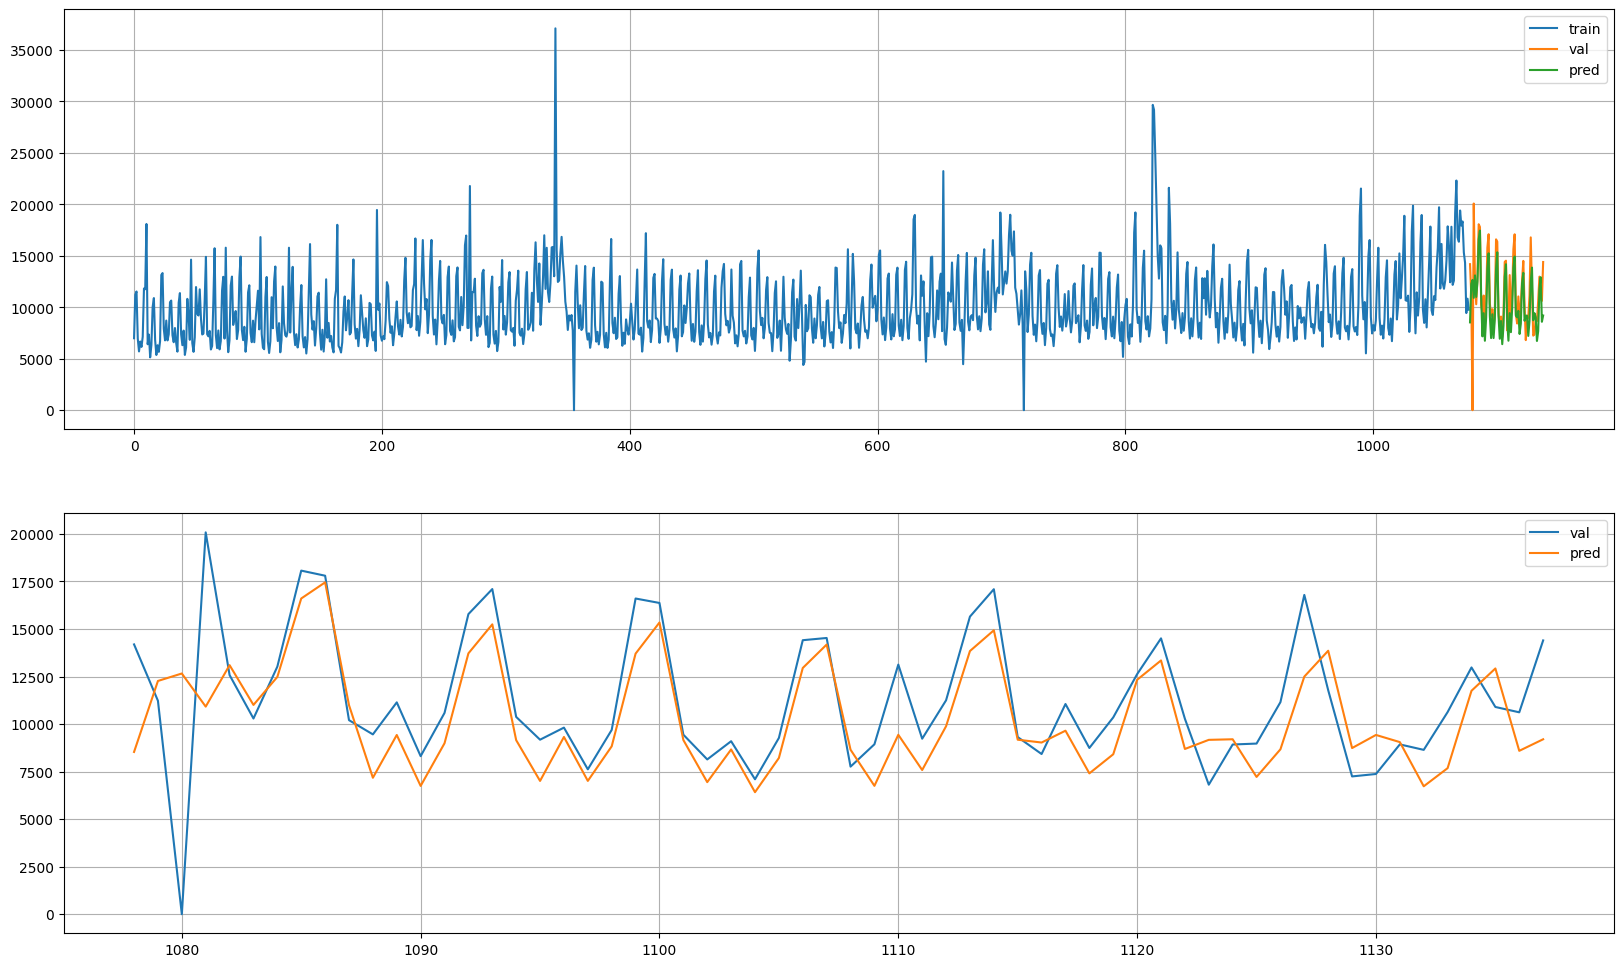

In [ ]:
y_train2 = y_train12 * (y_max - y_min) + y_min
plot_model_result(y_train2, y_val2, pred)

### **3) 상품 : 42 - Agricultural products**

* **데이터 준비**

In [ ]:
def temporalize(x, y, timesteps):
    output_X = []
    output_y = []
    for i in range(len(x) - timesteps + 1):
        output_X.append(x.iloc[i:i+timesteps])
        output_y.append(y.iloc[i+timesteps-1])
    return np.array(output_X), np.array(output_y)

In [ ]:
def preproc3d(data, timesteps, y_scale = False) :
    target = 'target'
    x = data.drop(['Date', target], axis = 1)
    y = data.loc[:, target]

    # 가변수화
    x['WeekDay'] = pd.Categorical(x['WeekDay'], categories = ['Monday', 'Tuesday', 'Wednesday','Thursday', 'Friday', 'Saturday', 'Sunday' ])
    x['Month'] = pd.Categorical(x['Month'], categories = [1,2,3,4,5,6,7,8,9,10,11,12])
    x = pd.get_dummies(x, columns = ['WeekDay','Month'])
    col_names = list(x)


    # 스케일링
    scaler = MinMaxScaler()
    x = scaler.fit_transform(x)
    x = pd.DataFrame(x, columns=col_names)

    # y scale
    if y_scale == True :
        y_min, y_max = y.min(), y.max()
        y = (y - y_min) / (y_max - y_min)
    else :
        y_min, y_max = np.nan, np.nan

    # 3차원 변환
    x3, y3 = temporalize(x, y, timesteps)

    # 분할
    x_train, x_val, y_train, y_val = train_test_split(x3, y3, test_size = 120, shuffle = False)

    return x_train, x_val, y_train, y_val, scaler, y_min, y_max

In [ ]:
timesteps = 7
x_train_h, x_va_l_h, y_train_h, y_val_h, scaler_h, y_min, y_max = preproc3d(grocery, timesteps, True)
y_min, y_max

(45.0, 196.0)

* **모델링**

In [ ]:
from keras.layers import Dropout
clear_session()

_, ts, nfeat = x_train_h.shape

LSTM_model = Sequential([LSTM(4, input_shape = (ts, nfeat), return_sequences=True ),
                        LSTM(8, return_sequences=True),
                        LSTM(16, return_sequences=True),
                        LSTM(32, return_sequences=True),
                        LSTM(64, return_sequences=True),
                        LSTM(32, return_sequences=True),
                        LSTM(16, return_sequences=True),
                        LSTM(8, return_sequences=True),
                        LSTM(4,),
                        Dense(1)
                         ])
LSTM_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 7, 4)                │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 7, 8)                │             416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 7, 16)               │           1,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 7, 32)               │           6,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 7, 64)               │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 7, 32)               │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 7, 16)               │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 7, 8)                │             800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_8 (LSTM)                        │ (None, 4)                   │             208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,133 (195.83 KB)

 Trainable params: 50,133 (195.83 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.1728 - val_loss: 0.0375
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0401 - val_loss: 0.0673
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0304 - val_loss: 0.0532
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0320 - val_loss: 0.0539
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0325 - val_loss: 0.0577
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0218 - val_loss: 0.0317
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0114 - val_loss: 0.0307
Epoch 8/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0104 - val_loss: 0.0301
Epoch 9/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0101 - val_loss: 0.0224
Epoch 10/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0086 - val_loss: 0.0221
Epoch 11/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0079 - val_loss: 0.0202
Epoch 12/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/ste

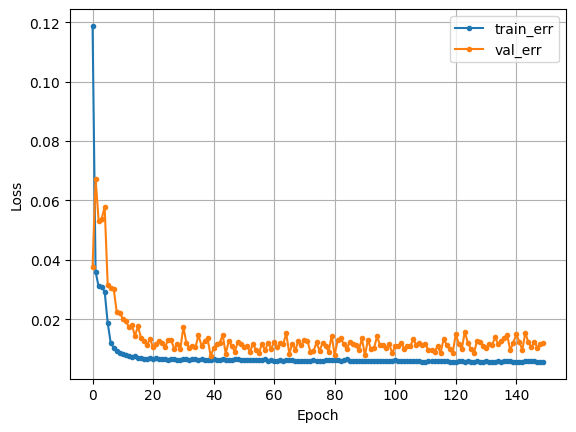

In [ ]:
LSTM_model.compile(optimizer = 'adam', loss = 'mse')
LSTM_hist = LSTM_model.fit(x_train_h, y_train_h, epochs = 150, validation_split = .2).history
dl_history_plot(LSTM_hist)

In [ ]:
pred = LSTM_model.predict(x_va_l_h)
pred = pred * (y_max - y_min) + y_min
y_val2 = y_val_h * (y_max - y_min) + y_min

print('MAE : ', mean_absolute_error(y_val2, pred))
print('MAPE : ',mean_absolute_percentage_error(y_val2, pred))
print('R2 : ',r2_score(y_val2, pred))

1/4 ━━━━━━━━━━━━━━━━━━━━ 2s 819ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 301ms/step
MAE :  13.086182975769043
MAPE :  0.11090488194247054
R2 :  0.5493416779748262


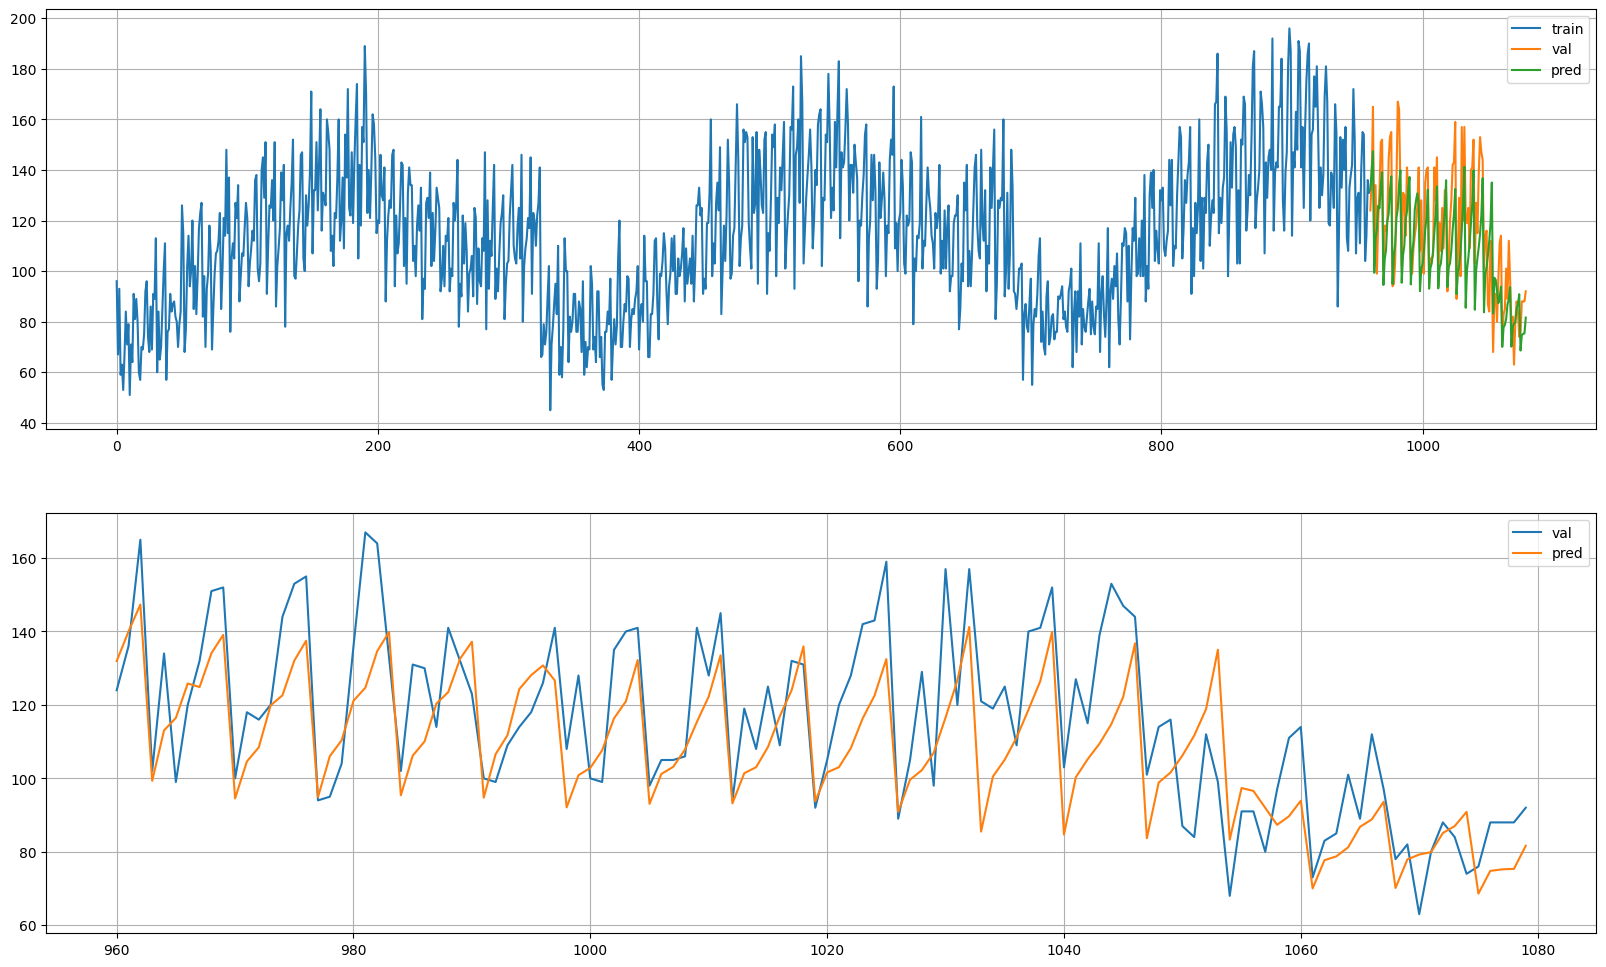

In [ ]:
y_train2 = y_train_h * (y_max - y_min) + y_min
plot_model_result(y_train2, y_val2, pred)

## **(2) CNN 모델링**

### **1) 상품 : 3 - Beverage**

* **데이터 준비**

In [24]:
x = df_bev.drop(columns=['2d_later'])
y = df_bev['2d_later']
timesteps = 7

x, y = temporalize(x, y, timesteps)

num_samples = x.shape[0]
num_features = 2

numeric_data = x[:, :, :num_features].reshape(-1, num_features).astype(float)

scaler = MinMaxScaler()
scaled_numeric_data = scaler.fit_transform(numeric_data)

scaled_numeric_data = scaled_numeric_data.reshape(num_samples, timesteps, num_features)

other_data = x[:, :, num_features:]

x = np.concatenate((scaled_numeric_data, other_data), axis=2)

In [25]:
x_train = x[:-60]
x_val = x[-60:]
y_train = y[:-60]
y_val = y[-60:]

x_train = x_train.astype(np.float32)
y_train = y_train.astype(np.float32)
x_val = x_val.astype(np.float32)
y_val = y_val.astype(np.float32)

* **모델링**

In [27]:
from keras.callbacks import EarlyStopping

model_b2 = Sequential()
model_b2.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
model_b2.add(Conv1D(filters=16, kernel_size=3, activation='relu'))
model_b2.add(Conv1D(filters=8, kernel_size=3, activation='relu'))
model_b2.add(Flatten())

model_b2.add(Dense(1))

model_b2.compile(optimizer=Adam(0.01), loss='mse', metrics=['mae'])

es = EarlyStopping(monitor='val_loss', min_delta=0, patience=50, restore_best_weights=True)

history = model_b2.fit(x_train, y_train, epochs=1000, validation_data=[x_val, y_val], callbacks=[es]).history

Epoch 1/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - loss: 48235788.0000 - mae: 5840.2544 - val_loss: 13376778.0000 - val_mae: 3088.8069
Epoch 2/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10840938.0000 - mae: 2514.4685 - val_loss: 10663201.0000 - val_mae: 2366.2500
Epoch 3/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7756770.0000 - mae: 2113.8765 - val_loss: 8162402.0000 - val_mae: 1983.8802
Epoch 4/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6165759.0000 - mae: 1871.5153 - val_loss: 7841248.0000 - val_mae: 1908.6698
Epoch 5/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6317258.0000 - mae: 1898.1969 - val_loss: 8439553.0000 - val_mae: 1986.8435
Epoch 6/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6248776.0000 - mae: 1863.1898 - val_loss: 7436473.5000 - val_mae: 1850.2729
Epoch 7/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5879954.5000 - mae: 1776.8420 - val_loss: 6887651.0000 - val_mae: 1849.1525
Epoch 8/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [ ]:
pred = model_b2.predict(x_val)

print('MAE : ', mean_absolute_error(y_val, pred))
print('MAPE : ',mean_absolute_percentage_error(y_val, pred))
print('R2 : ',r2_score(y_val, pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
MAE :  1653.1741
MAPE :  0.1447682
R2 :  0.613312840461731


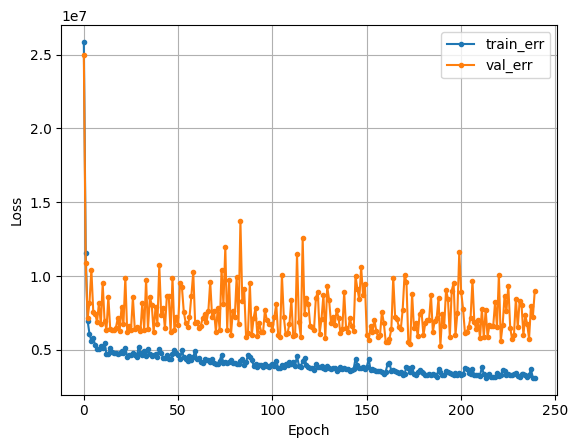

In [ ]:
dl_history_plot(history)

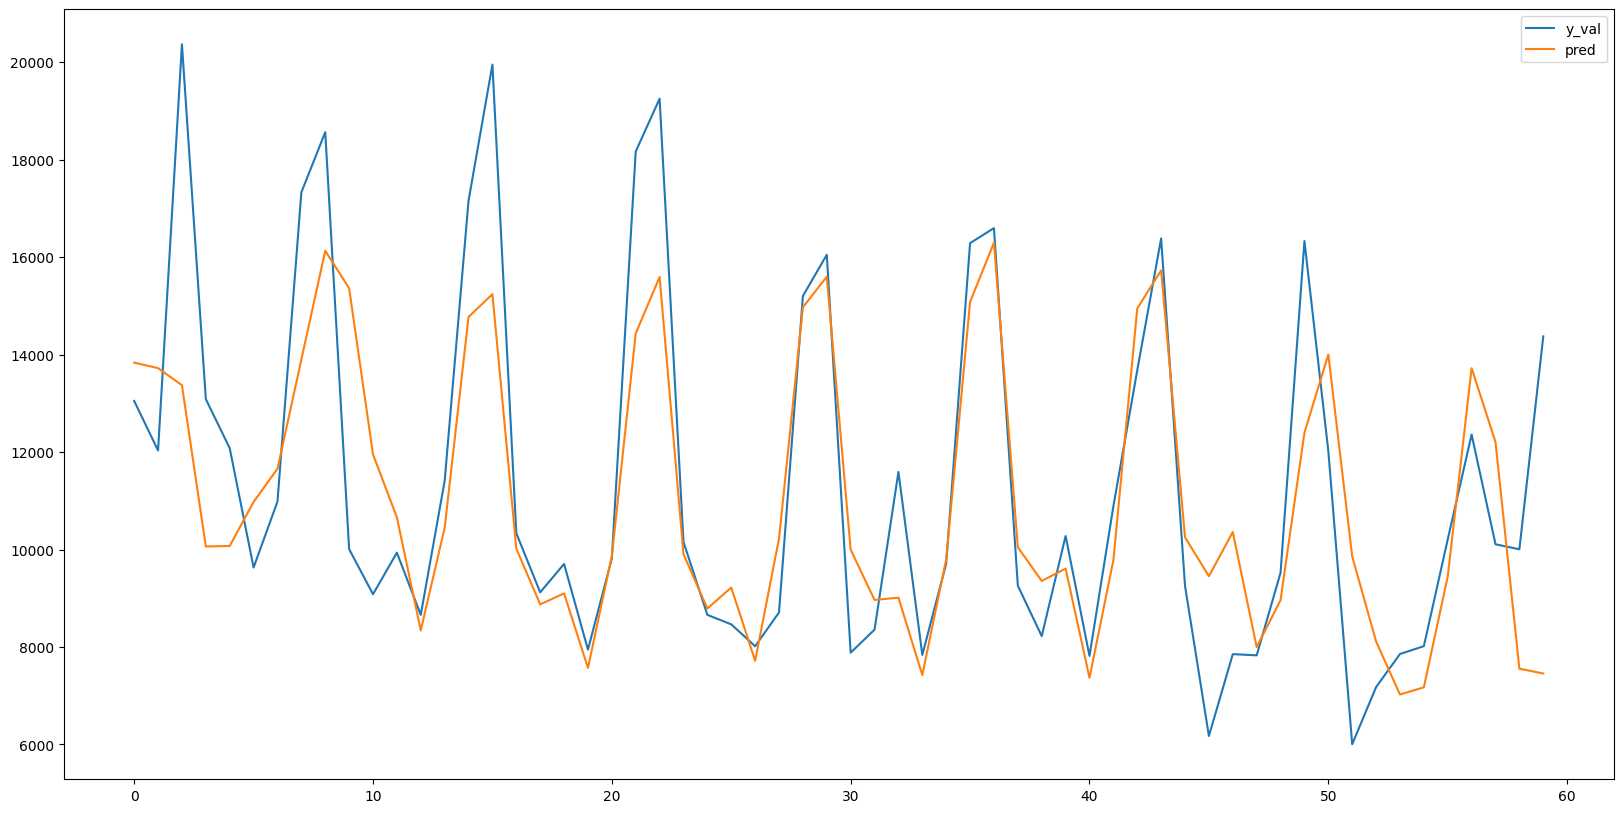

In [ ]:
plt.figure(figsize=(20,10))
plt.plot(y_test_org,label='y_val')
plt.plot(pred,label='pred')
plt.legend()
plt.show()

### **2) 상품 : 12 - Milk**

* **데이터 준비**

In [ ]:
def preproc3d(data, timesteps, y_scale = False) :
    target = 'Target_Qty'  # 타겟 변수 컬럼명 수정
    x = data.drop(['Date', target], axis=1)
    y = data[target]

    # 가변수화 (범주형 변수 처리)
    x['Weekday'] = pd.Categorical(x['Weekday'], categories = [0,1,2,3,4,5,6])
    x['Is_Weekend'] = pd.Categorical(x['Is_Weekend'], categories = [0,1])
    x['Month'] = pd.Categorical(x['Month'], categories = [1,2,3,4,5,6,7,8,9,10,11,12])
    x = pd.get_dummies(x, columns = ['Weekday', 'Month', 'Is_Weekend'], drop_first=True)
    col_names = list(x)

    # 스케일링
    scaler = MinMaxScaler()
    x = scaler.fit_transform(x)
    x = pd.DataFrame(x, columns=col_names)

    # y scale (0과 1 사이로 정규화)
    if y_scale:
        y_min, y_max = y.min(), y.max()
        y = (y - y_min) / (y_max - y_min)
    else:
        y_min, y_max = np.nan, np.nan

    # 3차원 변환
    x3, y3 = temporalize(x, y, timesteps)

    # 데이터 분할 (훈련 세트, 검증 세트)
    x_train, x_val, y_train, y_val = train_test_split(x3, y3, test_size=60, shuffle=False)

    return x_train, x_val, y_train, y_val, scaler, y_min, y_max

In [ ]:
timesteps = 7
x_train12, x_val12, y_train12, y_val12, scaler, y_min, y_max = preproc3d(milk, timesteps, True)
y_min, y_max, x_train.shape, x_val.shape

(0.0, 37106.0, (1078, 7, 16), (60, 7, 16))

* **모델링**

In [ ]:
clear_session()

_, ts, nfeat = x_train12.shape

model12_02 = Sequential([Conv1D(4, 3, input_shape = (ts, nfeat), activation='relu', padding = 'same'),
                         Flatten(),
                         Dense(1)])
model12_02.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 7, 4)                │             280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 28)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              29 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 309 (1.21 KB)

 Trainable params: 309 (1.21 KB)

 Non-trainable params: 0 (0.00 B)

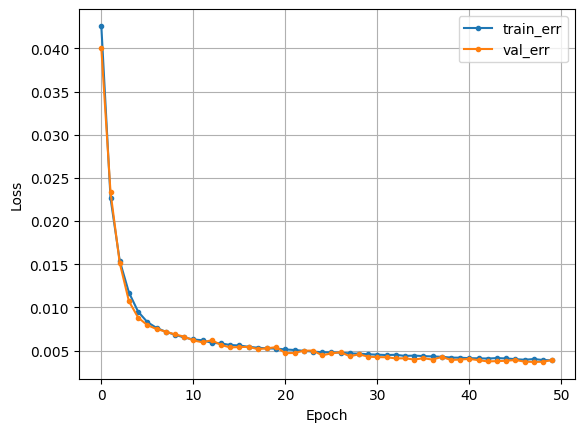

In [ ]:
model12_02.compile(optimizer = 'adam', loss = 'mse')
hist = model12_02.fit(x_train12, y_train12, epochs = 50, validation_split = .2, verbose = 0).history
dl_history_plot(hist)

In [ ]:
# 스케일링 된 데이터 돌려서 평가하기
pred = model12_02.predict(x_val12)
pred = pred * (y_max - y_min) + y_min
y_val2 = y_val12 * (y_max - y_min) + y_min

print('MAE : ', mean_absolute_error(y_val2, pred))
print('MAPE : ',mean_absolute_percentage_error(y_val2, pred))
print('R2 : ',r2_score(y_val2, pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
MAE :  2840.953645833333
MAPE :  8.382224384381332e+17
R2 :  -0.2468051576120187


In [ ]:
from keras.layers import MaxPooling1D

model12_03 = Sequential()

model12_03.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same', input_shape=(ts, nfeat)))
model12_03.add(MaxPooling1D(pool_size=2))
model12_03.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
model12_03.add(MaxPooling1D(pool_size=2))
model12_03.add(LSTM(100, return_sequences=False))
model12_03.add(Dense(1))
model12_03.compile(optimizer='adam', loss='mse')
model12_03.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)                    │ (None, 7, 128)              │           8,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 3, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 3, 128)              │          49,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 1, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 100)                 │          91,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 149,941 (585.71 KB)

 Trainable params: 149,941 (585.71 KB)

 Non-trainable params: 0 (0.00 B)

### **3) 상품 : 42 - Agricultural products**

* **데이터 준비**

In [ ]:
timesteps = 7
x_train_h, x_val_h, y_train_h, y_val_h, scaler_h, y_min, y_max = preproc3d(grocery, timesteps, True)
y_min, y_max, x_train_h.shape, x_val_h.shape

(45.0, 196.0, (960, 7, 23), (120, 7, 23))

* **모델링**

In [ ]:
from keras.layers import Conv2D
clear_session()

_, ts, nfeat = x_train_h.shape

CNN_model = Sequential([Conv1D(4, 3, input_shape = (ts, nfeat), activation='relu', padding = 'same'),
                         Flatten(),
                         Dense(1)])
CNN_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 7, 4)                │             280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 28)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              29 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 309 (1.21 KB)

 Trainable params: 309 (1.21 KB)

 Non-trainable params: 0 (0.00 B)

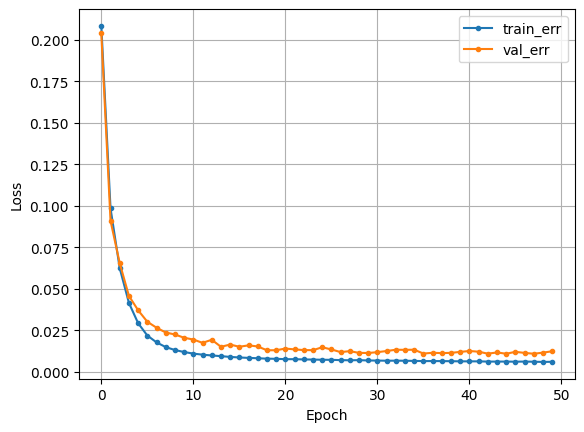

In [ ]:
CNN_model.compile(optimizer = 'adam', loss = 'mse')
CNN_hist = CNN_model.fit(x_train_h, y_train_h, epochs = 50, validation_split = .2, verbose = 0).history
dl_history_plot(CNN_hist)

In [ ]:
pred = CNN_model.predict(x_val_h)
pred = pred * (y_max - y_min) + y_min
y_val2 = y_val_h * (y_max - y_min) + y_min

print('MAE : ', mean_absolute_error(y_val2, pred))
print('MAPE : ',mean_absolute_percentage_error(y_val2, pred))
print('R2 : ',r2_score(y_val2, pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
MAE :  14.084248860677084
MAPE :  0.12221158158880417
R2 :  0.5085186881443525


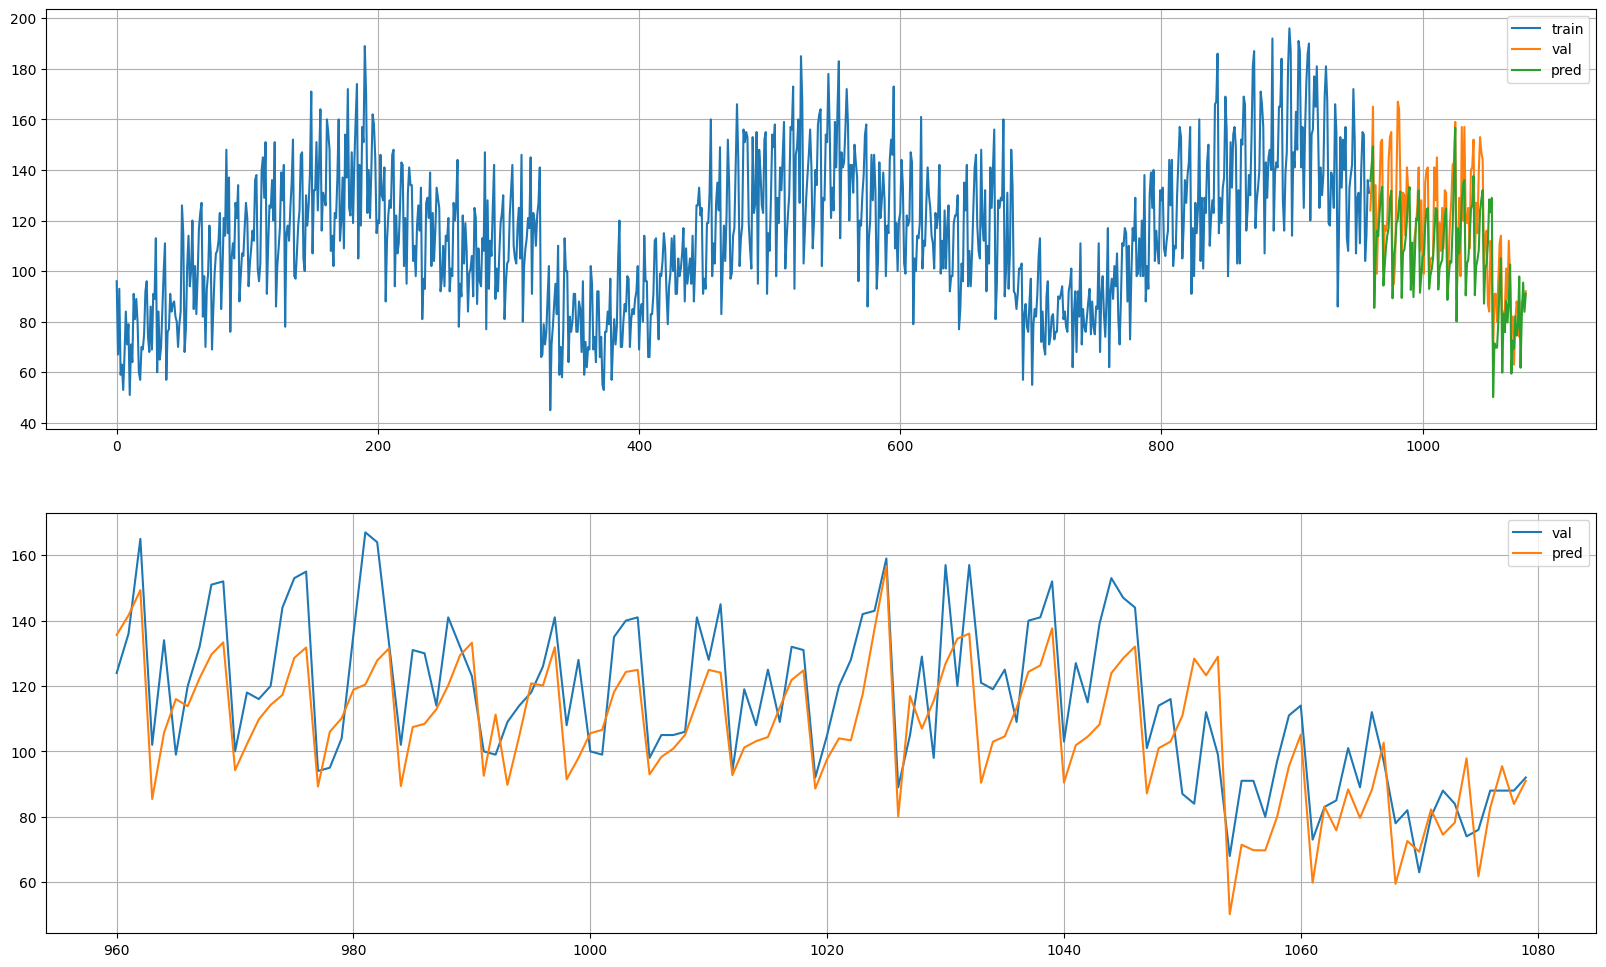

In [ ]:
y_train2 = y_train_h * (y_max - y_min) + y_min
plot_model_result(y_train2, y_val2, pred)

# **3.데이터 파이프라인 생성**

* 세부 요구사항
    * 데이터 파이프라인 함수 작성하기
        * input : raw data(sales_test, orders_test, oil_price_test, products, stores)
        * output : x_test, y_test
        * test set으로 파이프라인 함수를 테스트 해 봅시다.

## **(1) 파이프라인 함수 생성**

In [7]:
path = '/content/gdrive/Othercomputers/내 노트북/aivle6-practice/mini-project-6/'
oil_price_test = pd.read_csv(path + 'test/oil_price_test.csv')
orders_test = pd.read_csv(path + 'test/orders_test.csv')
sales_test = pd.read_csv(path + 'test/sales_test.csv')
products = pd.read_csv(path + 'test/products.csv')
stores = pd.read_csv(path + 'test/stores.csv')

sales_test['Date'] = pd.to_datetime(sales_test['Date'] )
oil_price_test['Date'] = pd.to_datetime(oil_price_test['Date'] )
orders_test['Date'] = pd.to_datetime(orders_test['Date'] )

In [ ]:
def temporalize(x, y, timesteps):
    output_X = []
    output_y = []
    for i in range(len(x) - timesteps + 1):
        output_X.append(x.iloc[i:i+timesteps])
        output_y.append(y.iloc[i+timesteps-1])
    return np.array(output_X), np.array(output_y)

In [8]:
#Beverage
def make_dataset3(orders_test, products_test, sales_test, oil_price_test):
  sales_test['Date'] = pd.to_datetime(sales_test['Date'] )
  oil_price_test['Date'] = pd.to_datetime(oil_price_test['Date'] )
  orders_test['Date'] = pd.to_datetime(orders_test['Date'] )
  order_test_44 = orders_test.loc[orders_test['Store_ID'] == 44]
  sales_test_44 = sales_test.loc[(sales_test['Store_ID'] == 44)]

  t1 = pd.merge(order_test_44, sales_test_44, how='inner')
  t2 = pd.merge(t1, products_test, on='Product_ID', how='outer')
  t2.drop(columns=['Store_ID', 'CustomerCount', 'Product_ID', 'Product_Code', 'Category', 'LeadTime', 'Price'], inplace=True)
  f_pivoted_test = t2.pivot_table(index='Date', columns='SubCategory', values='Qty', aggfunc='sum')
  df_pivoted_test = t2.pivot_table(index='Date', columns='SubCategory', values='Qty', aggfunc='sum')
  correlation_matrix = df_pivoted_test.corr()
  beverage_corr = correlation_matrix['Beverage']
  beverage_corr.sort_values(ascending=False)
  id_test = 44

  order_44_test = orders_test.loc[orders_test['Store_ID'] == id_test]

  drink_test = products_test.loc[products_test['SubCategory'] == 'Beverage']

  sales_44_test = sales_test.loc[(sales_test['Store_ID'] == id_test) & (sales_test['Product_ID'] == 3)]

  t1_test = pd.merge(order_44_test, sales_44_test, how='inner')
  t2_test = pd.merge(t1_test, order_44_test, how='inner')
  df_bev_oil_test = pd.merge(t2_test, oil_price_test, how='outer')

  df_bev_oil_test.drop(columns=['Store_ID', 'Product_ID'], inplace=True)
  df_bev_oil_test['day'] = df_bev_oil_test['Date'].dt.weekday
  df_bev_oil_test['month'] = df_bev_oil_test['Date'].dt.month
  df_bev_oil_test['WTI_Price'] = df_bev_oil_test['WTI_Price'].interpolate(method='linear')
  df_bev_oil_test['CustomerCount'] = df_bev_oil_test['CustomerCount'].interpolate(method='linear')
  df_bev_oil_test['Qty'] = df_bev_oil_test['Qty'].interpolate(method='linear')
  df_bev_oil_test['season']=df_bev_oil_test['month'].map({1:4,2:4,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:4,12:4})

  df_bev_test = pd.merge(df_bev_oil_test, df_pivoted_test[['BAKERY', 'Home Appliances', 'Yogurt']], on='Date')
  df_bev_test.drop(columns=['Date'],inplace=True)
  df_bev_test['2d_later']=df_bev_test['Qty'].shift(-2)
  df_bev_test.dropna(inplace=True)
  df_bev_test=pd.get_dummies(data=df_bev_test,columns=['day','season'],drop_first=True)
  df_bev_test['season_2'] = False
  df_bev_test['season_3'] = False
  df_bev_test['season_4'] = False

  return df_bev_test

In [ ]:
#milk
def make_dataset(Product_ID):

    # 판매 데이터에서 상품 ID에 맞는 데이터만 필터링
    product_sales = sales_test[sales_test['Product_ID'] == Product_ID].copy()

    # 44번 매장 데이터만 필터링
    product_sales = product_sales[product_sales['Store_ID'] == 44]

    # 주문 데이터와 병합하여 고객 방문 수를 추가
    product_sales = product_sales.merge(
        orders_test[['Date', 'Store_ID', 'CustomerCount']],
        on=['Date', 'Store_ID'],
        how='left'
    )

    # 유가 데이터의 결측치를 선형 보간
    oil_price_test['WTI_Price'] = oil_price_test['WTI_Price'].interpolate(method='linear')

    # 유가 7일 이동 평균 계산
    oil_price_test['WTI_Price'] = oil_price_test['WTI_Price'].rolling(window=7, min_periods=1).mean()

    # 유가 데이터와 병합
    product_sales = product_sales.merge(oil_price_test[['Date', 'WTI_Price']], on='Date', how='left')

    # 결측치 채우기
    product_sales['WTI_Price'].fillna(method='ffill', inplace=True)

    product_sales['Year'] = product_sales['Date'].dt.year
    product_sales['Month'] = product_sales['Date'].dt.month
    product_sales['Day'] = product_sales['Date'].dt.day
    product_sales['Weekday'] = product_sales['Date'].dt.weekday
    product_sales['Is_Weekend'] = product_sales['Weekday'].apply(lambda x: 1 if x >= 5 else 0)

    # 전날 판매량 추가
    product_sales['Prev_Qty'] = product_sales['Qty'].shift(1)
    product_sales['Prev_Qty'].fillna(0, inplace=True)

    # 주간 판매량 합산 계산
    product_sales['Date'] = pd.to_datetime(product_sales['Date'])
    product_sales['Week'] = product_sales['Date'].dt.isocalendar().week
    weekly_sales = product_sales.groupby(['Store_ID', 'Product_ID', 'Year', 'Week'])['Qty'].sum().reset_index()
    product_sales = product_sales.merge(weekly_sales, on=['Store_ID', 'Product_ID', 'Year', 'Week'], suffixes=('', '_Weekly'))

    # 타겟 변수 설정 (2일 후 판매량)
    product_sales['Target_Qty'] = product_sales['Qty'].shift(-2)
    product_sales = product_sales.drop(index=0)
    product_sales = product_sales.dropna()

    # 지정된 컬럼 삭제
    product_sales = product_sales.drop(columns=['Store_ID', 'Product_ID', 'Day', 'Week', 'Year'])

    return product_sales

In [ ]:
#Grocery
def make_grocery(orders_test, products_test, sales_test, oil_price_test):
  df_hk = pd.merge(sales_test, stores, how = 'inner', on = 'Store_ID')
  df_hk = pd.merge(df_hk, products_test, how = 'inner', on = 'Product_ID')
  df_hk = pd.merge(df_hk, oil_price_test, how = 'left', on = 'Date')
  df_hk = pd.merge(df_hk, orders_test, how = 'inner', on = ['Date', 'Store_ID'])
  df_hk = df_hk.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')

  category = df_hk.loc[(df_hk['Store_ID'] == 44) & (df_hk['Category'] == 'Grocery')]
  meat = category.loc[category['SubCategory'] == 'Meats'][['Qty','Date']]
  meat = meat.rename(columns={'Qty': 'meat_Qty'})
  tdf = df_hk.loc[(df_hk['Store_ID'] == 44) & (df_hk['Product_ID']==42)]
  tdf = pd.merge(tdf, meat, how = 'left', on = 'Date')

  tdf['WeekDay'] = tdf['Date'].dt.day_name()
  tdf['Month'] =  tdf['Date'].dt.month
  st_df = tdf.drop(['Store_ID','LeadTime','Store_Type','City', 'State','SubCategory','Product_Code','Category','Product_ID','Price'], axis=1)
  return st_df

## **(2) test 데이터로 확인**

* test용 데이터셋들 로딩

In [9]:
beverage_test = make_dataset3(orders_test, products, sales_test, oil_price_test)
beverage_test.head()


,CustomerCount,Qty,WTI_Price,month,BAKERY,Home Appliances,Yogurt,2d_later,day_1,day_2,day_3,day_4,day_5,day_6,season_2,season_3,season_4
0,4146,10153.0,53.820000,3,1745.503,28.0,3031.0,10257.0,False,True,False,False,False,False,False,False,False
1,3882,8918.0,52.630000,3,1407.037,51.0,2234.0,16991.0,False,False,True,False,False,False,False,False,False
2,4483,10257.0,53.330000,3,1710.550,29.0,2888.0,18304.0,False,False,False,True,False,False,False,False,False
3,5382,16991.0,53.283333,3,2430.925,53.0,4317.0,8413.0,False,False,False,False,True,False,False,False,False
4,5423,18304.0,53.236667,3,2742.407,74.0,4579.0,8360.0,False,False,False,False,False,True,False,False,False


In [ ]:
milk_test = make_dataset(12)
milk_test.head()

,Date,Qty,CustomerCount,WTI_Price,Month,Weekday,Is_Weekend,Prev_Qty,Qty_Weekly,Target_Qty
1,2017-03-02,9761.0,3882,53.2250,3,3,0,11307.0,67633.0,16590.0
2,2017-03-03,11207.0,4483,53.2600,3,4,0,9761.0,67633.0,18768.0
3,2017-03-04,16590.0,5382,53.2600,3,5,1,11207.0,67633.0,8985.0
4,2017-03-05,18768.0,5423,53.2600,3,6,1,16590.0,67633.0,8678.0
5,2017-03-06,8985.0,3882,53.2425,3,0,0,18768.0,74789.0,8965.0


In [ ]:
grocery_test = make_grocery(orders_test, products, sales_test, oil_price_test)
grocery_test.head()

,Date,Qty,WTI_Price,CustomerCount,meat_Qty,WeekDay,Month
0,2017-03-01,106.0,53.820000,4146,918.9270,Wednesday,3
1,2017-03-02,138.0,53.225000,3882,798.9650,Thursday,3
2,2017-03-03,106.0,53.260000,4483,1475.8910,Friday,3
3,2017-03-04,144.0,53.252761,5382,1278.0859,Saturday,3
4,2017-03-05,152.0,53.244016,5423,1409.7570,Sunday,3


In [14]:
def preprocessing4predict(df, product_ID = 3, timesteps = 7,y_scale =True):
  if product_ID == 3 :

    x = df.drop(columns=['2d_later'])
    y = df['2d_later']
    timesteps = 7

    x, y = temporalize(x, y, timesteps)

    num_samples = x.shape[0]
    num_features = 2

    numeric_data = x[:, :, :num_features].reshape(-1, num_features).astype(float)

    scaler = MinMaxScaler()
    scaled_numeric_data = scaler.fit_transform(numeric_data)

    scaled_numeric_data = scaled_numeric_data.reshape(num_samples, timesteps, num_features)

    other_data = x[:, :, num_features:]

    x = np.concatenate((scaled_numeric_data, other_data), axis=2)
    x = x.astype(np.float32)
    y = y.astype(np.float32)

    return x, y

  elif product_ID == 12 :
    target = 'Target_Qty'  # 타겟 변수 컬럼명 수정
    x = df.drop(['Date', target], axis=1)
    y = df[target]

    # 가변수화 (범주형 변수 처리)
    x['Weekday'] = pd.Categorical(x['Weekday'], categories = [0,1,2,3,4,5,6])
    x['Is_Weekend'] = pd.Categorical(x['Is_Weekend'], categories = [0,1])
    x['Month'] = pd.Categorical(x['Month'], categories = [1,2,3,4,5,6,7,8,9,10,11,12])
    x = pd.get_dummies(x, columns = ['Weekday', 'Month', 'Is_Weekend'], drop_first=True)
    col_names = list(x)

    # 스케일링
    scaler = MinMaxScaler()
    x = scaler.fit_transform(x)
    x = pd.DataFrame(x, columns=col_names)

    # y scale (0과 1 사이로 정규화)
    if y_scale:
        y_min, y_max = y.min(), y.max()
        y = (y - y_min) / (y_max - y_min)
    else:
        y_min, y_max = np.nan, np.nan

    # 3차원 변환
    x3, y3 = temporalize(x, y, timesteps)

    return x3, y3

  if product_ID == 42 :
    df['target'] = df['Qty'].shift(-2)
    df.dropna(inplace = True)
    target = 'target'
    x = df.drop(['Date', target], axis = 1)
    y = df.loc[:, target]

    # 가변수화
    x['WeekDay'] = pd.Categorical(x['WeekDay'], categories = ['Monday', 'Tuesday', 'Wednesday','Thursday', 'Friday', 'Saturday', 'Sunday' ])
    x['Month'] = pd.Categorical(x['Month'], categories = [1,2,3,4,5,6,7,8,9,10,11,12])
    x = pd.get_dummies(x, columns = ['WeekDay','Month'])
    col_names = list(x)


    # 스케일링
    scaler = MinMaxScaler()
    x = scaler.fit_transform(x)
    x = pd.DataFrame(x, columns=col_names)

    # y scale
    if y_scale == True :
        y_min, y_max = y.min(), y.max()
        y = (y - y_min) / (y_max - y_min)
    else :
        y_min, y_max = np.nan, np.nan

    # 3차원 변환
    x3, y3 = temporalize(x, y, timesteps)

    return x3, y3

In [28]:
x, y = preprocessing4predict(beverage_test, product_ID = 3, timesteps = 7,y_scale =True)

In [29]:
pred = model_b2.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step


* 예측해보기

In [30]:
r2_score(y, pred)

0.8305540680885315

# **4.비즈니스 평가**

* 세부 요구사항
    * 기본 시뮬레이션 함수가 제공됩니다.
        * 필요하다면 해당 함수를 수정해서 사용할 수 있습니다.
    * 시뮬레이션 함수 사용하여 재고 평가
        * 실제값, 예측값, 안전재고 수량을 넣고 일평균 재고 금액을 확인합니다.
        * 기회손실수량은 0으로 맞추도록 안전재고 수량을 조절합니다.
        * 평균재고금액을 확인합니다.
    * 데이터는 test 셋을 이용합니다.
        * 예측 후 재고 평가 시, 스케일링된 y를 원래대로 돌려 놓아야 합니다.
            * y_real = y_sacled * (y_max - y_min) + y_min
            * pred_real = pred * (y_max - y_min) + y_min

## **(1) 재고 시뮬레이터**

In [ ]:
def inv_simulator(y, pred, safe_stock, price) :

    # 시뮬레이션 df 틀 만들기
    temp = pd.DataFrame({'y':y.reshape(-1,), 'pred':pred.reshape(-1,).round()})

    temp['base_stock'] = 0
    temp['close_stock'] = 0
    temp['order'] = 0
    temp['receive'] = 0

    # 시뮬레이션

    for i in range(len(temp)-2):  # 발주량은 leadtime 후 판매 예측량에 기초하므로 계산을 위해 마지막 leadtime 만큼의 행 제외
        if i == 0 : #첫 행. 2일 전 데이터가 없으므로,
            temp.loc[ i ,'receive'] = temp.loc[ i ,'y']  # 입고량은 실판매량으로 계산
            temp.loc[ i ,'base_stock'] = temp.loc[ i ,'receive'] + safe_stock  # 기초재고는 실판매량 + 안전재고로 계산

        elif i == 1 : # 둘째 행, 2일 전 데이터가 없음.
            temp.loc[ i ,'receive'] = temp.loc[ i ,'y'] # 입고량은 실판매량으로 계산
            temp.loc[ i ,'base_stock'] = temp.loc[ i ,'receive'] + temp.loc[ i-1 ,'close_stock']
        else :      # 나머지 전체 행.
            temp.loc[ i ,'receive'] = temp.loc[ i-2 ,'order']    # 입고량 = 2일전 발주량
            temp.loc[ i ,'base_stock'] = temp.loc[ i ,'receive'] + temp.loc[ i-1 ,'close_stock']  # 기초재고 = 입고량 + 전날 기말재고

        # 기말재고 = 기초재고 - 판매량,  만약 0보다 작으면 0으로.
        stock = round(temp.loc[i, 'base_stock'] - temp.loc[i, 'y'])
        temp.loc[i, 'close_stock'] = np.where(stock> 0, stock, 0)

        # 발주량 = 2일후 판매예측량 + 안전재고 - 기말재고,  만약 주문량이 0보다 작으면 0
        order = temp.loc[i+2, 'pred'] + safe_stock - temp.loc[i, 'close_stock']
        temp.loc[i, 'order'] = np.where(order>0,order, 0)

    # 기회손실 = 만약 (기초재고 - 실판매량)이 0보다 작으면, 그만큼이 기회손실
    temp['lost'] = np.where((temp['base_stock'] - temp['y'])<0, (temp['base_stock'] - temp['y']),0).round()

    inventory = temp[:len(temp)-2]

    # 측정지표 계산
    DailyStock = ((inventory['base_stock'] + inventory['close_stock'])/2)
    DailyTurnover = (inventory['y'] + inventory['lost']) / DailyStock

    AvgDailyStock = round(DailyStock.mean(),3)
    AvgDailyStockAmt = AvgDailyStock * price
    turnover = round(DailyTurnover.mean(), 3)
    lost_sum = inventory['lost'].sum()


    print(f'일평균 재고량     : {AvgDailyStock}')
    print(f'일평균 재고 금액  : {AvgDailyStockAmt}')
    print(f'일평균 재고회전율 : {turnover}')
    print(f'기회손실 수량     : {lost_sum}')

    return inventory

## **(2) 예측 결과 시뮬레이션(재고금액 평가)**
